### **Autor**: David Roca Tauste

---

# 📌**ACTIVIDAD 1: REPASAR ALGORITMOS**

---
# REGRESIÓN LINEAL MÚLTIPLE

In [87]:
import pandas as pd

df = pd.read_csv("50_startups.csv")

predictoras = df[["R&D Spend", "Marketing Spend", "State"]]
target = df["Profit"]

print("Primeros 5 ejemplos:")
print(predictoras.head().values)

Primeros 5 ejemplos:
[[165349.2 471784.1 'New York']
 [162597.7 443898.53 'California']
 [153441.51 407934.54 'Florida']
 [144372.41 383199.62 'New York']
 [142107.34 366168.42 'Florida']]


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

column_transformer = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(drop="first"), ["State"])
    ], remainder="passthrough"
)

predictoras_encoded = column_transformer.fit_transform(predictoras)

nombres_columnas = column_transformer.get_feature_names_out()
predictoras_encoded_df = pd.DataFrame(predictoras_encoded, columns=nombres_columnas)

print("Después de aplicar OneHotEncoder a la característica 'State':")
print(predictoras_encoded_df.head())

Después de aplicar OneHotEncoder a la característica 'State':
   encoder__State_Florida  encoder__State_New York  remainder__R&D Spend  \
0                     0.0                      1.0             165349.20   
1                     0.0                      0.0             162597.70   
2                     1.0                      0.0             153441.51   
3                     0.0                      1.0             144372.41   
4                     1.0                      0.0             142107.34   

   remainder__Marketing Spend  
0                   471784.10  
1                   443898.53  
2                   407934.54  
3                   383199.62  
4                   366168.42  


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    predictoras_encoded_df, target, test_size=0.2, random_state=123
)

print("X_train 5 primeras filas:")
print(X_train.head())
print("\ny_train 5 primeras filas:")
print(y_train.head())
print("\nX_test 5 primeras filas:")
print(X_test.head())
print("\ny_test 5 primeras filas:")
print(y_test.head())

X_train 5 primeras filas:
    encoder__State_Florida  encoder__State_New York  remainder__R&D Spend  \
21                     0.0                      1.0              78389.47   
47                     0.0                      0.0                  0.00   
11                     0.0                      0.0             100671.96   
41                     1.0                      0.0              27892.92   
5                      0.0                      1.0             131876.90   

    remainder__Marketing Spend  
21                   299737.29  
47                        0.00  
11                   249744.55  
41                   164470.71  
5                    362861.36  

y_train 5 primeras filas:
21    111313.02
47     42559.73
11    144259.40
41     77798.83
5     156991.12
Name: Profit, dtype: float64

X_test 5 primeras filas:
    encoder__State_Florida  encoder__State_New York  remainder__R&D Spend  \
10                     1.0                      0.0             101913.08 

In [90]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Scores del modelo:")
print(f" - Train: {train_score}")
print(f" - Test: {test_score}")

Scores del modelo:
 - Train: 0.944872235399549
 - Test: 0.965754198932209


## ENTREGA 1: Muestra:

### a) Capturas de ejecución y el código.
Está arriba.

### b) ¿Qué significa en este caso que el score sea aproximadamente del 0.966 en los datos de test?
Significa que el modelo acierta el 96'6% de las predicciones en los datos de test, a partir de las variables predictoras R&D Spend, Marketing Spend y State. Esto indica de que se trata de un muy buen modelo ya que, además, no muestra signos de sobreajuste.

In [91]:
import numpy as np

def calcular_sse(y_real, y_pred):
    return np.sum((y_real - y_pred) ** 2)

def calcular_sst(y_real):
    y_media = np.mean(y_real)
    return np.sum((y_real - y_media) ** 2)

def calcular_r2(y_real, y_pred):
    sse = calcular_sse(y_real, y_pred)
    sst = calcular_sst(y_real)
    return 1 - (sse / sst)

def calcular_r2_ajustado(y_real, y_pred, n, p):
    r2 = calcular_r2(y_real, y_pred)
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calcular valores para datos de entrenamiento
sse_train = calcular_sse(y_train, y_train_pred)
sst_train = calcular_sst(y_train)
ssr_train = sst_train - sse_train
r2_train = calcular_r2(y_train, y_train_pred)
r2_ajustado_train = calcular_r2_ajustado(y_train, y_train_pred, len(y_train), 1)

# Calcular valores para datos de prueba
sse_test = calcular_sse(y_test, y_test_pred)
sst_test = calcular_sst(y_test)
ssr_test = sst_test - sse_test
r2_test = calcular_r2(y_test, y_test_pred)
r2_ajustado_test = calcular_r2_ajustado(y_test, y_test_pred, len(y_test), 1)

# Imprimir resultados
print("Métricas para datos de train:")
print(f"SSE: {sse_train}")
print(f"SST: {sst_train}")
print(f"SSR: {ssr_train}")
print(f"R²: {r2_train}")
print(f"R² ajustado: {r2_ajustado_train}\n")

print("Métricas para datos de test:")
print(f"SSE: {sse_test}")
print(f"SST: {sst_test}")
print(f"SSR: {ssr_test}")
print(f"R²: {r2_test}")
print(f"R² ajustado: {r2_ajustado_test}")

Métricas para datos de train:
SSE: 3489621036.392025
SST: 63300608353.770935
SSR: 59810987317.37891
R²: 0.944872235399549
R² ajustado: 0.9434215047521687

Métricas para datos de test:
SSE: 516139212.6673195
SST: 15071605761.115088
SSR: 14555466548.447767
R²: 0.965754198932209
R² ajustado: 0.9614734737987352


In [92]:
df = pd.read_csv("50_startups.csv")
seed = 123

X = df[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]
y = df['Profit']

encoder = OneHotEncoder(drop='first', sparse_output=False)
state_codificado = encoder.fit_transform(df[['State']])
state_codificado_df = pd.DataFrame(state_codificado, columns=encoder.get_feature_names_out(['State']))

X = pd.concat([df[['R&D Spend', 'Administration', 'Marketing Spend']], state_codificado_df], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

model = LinearRegression()
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Scores del modelo:")
print(f" - Train: {train_score}")
print(f" - Test: {test_score}")

Scores del modelo:
 - Train: 0.9449965926433526
 - Test: 0.9667998486975283


In [93]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calcular valores para datos de entrenamiento
sse_train = calcular_sse(y_train, y_train_pred)
sst_train = calcular_sst(y_train)
ssr_train = sst_train - sse_train
r2_train = calcular_r2(y_train, y_train_pred)
r2_ajustado_train = calcular_r2_ajustado(y_train, y_train_pred, len(y_train), 1)

# Calcular valores para datos de prueba
sse_test = calcular_sse(y_test, y_test_pred)
sst_test = calcular_sst(y_test)
ssr_test = sst_test - sse_test
r2_test = calcular_r2(y_test, y_test_pred)
r2_ajustado_test = calcular_r2_ajustado(y_test, y_test_pred, len(y_test), 1)

# Imprimir resultados
print("Métricas para datos de train:")
print(f"SSE: {sse_train}")
print(f"SST: {sst_train}")
print(f"SSR: {ssr_train}")
print(f"R²: {r2_train}")
print(f"R² ajustado: {r2_ajustado_train}\n")

print("Métricas para datos de test:")
print(f"SSE: {sse_test}")
print(f"SST: {sst_test}")
print(f"SSR: {ssr_test}")
print(f"R²: {r2_test}")
print(f"R² ajustado: {r2_ajustado_test}")

Métricas para datos de train:
SSE: 3481749147.206061
SST: 63300608353.770935
SSR: 59818859206.56487
R²: 0.9449965926433526
R² ajustado: 0.9435491345550198

Métricas para datos de test:
SSE: 500379591.6402242
SST: 15071605761.115088
SSR: 14571226169.474863
R²: 0.9667998486975283
R² ajustado: 0.9626498297847194


## ENTREGA 2: Muestra:
### a) Capturas de ejecución y el código.
Está arriba.

### b) Haz una marca donde aumente el R2:
 - Train
 - `Test`

### c) Haz una marca donde aumente del R2 ajustado:
 - Train
 - `Test`

### d) ¿Dónde aparece mayor mejora? En el R2 o en el R2 ajustado.
En mi código no hay una métrica que sea mejor que la otra considerablemente, pero basándome en la captura de pantalla del PDF:
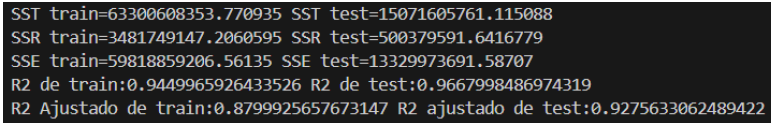

Aparece mayor mejora en el R2 ajustado, con una mejora casi del 5%.

### e) ¿Marca lo que calcula score() en scikit-learn?
 - SSE
 - SST
 - SSR
 - `R2`
 - R2 ajustado

---
# K-NN

In [94]:
from sklearn.neighbors import KNeighborsRegressor

# Crear y entrenar el modelo K-Nearest Neighbors, por ejemplo 3-NN
modelo_knn = KNeighborsRegressor(n_neighbors=3)
modelo_knn.fit(X_train, y_train)

# Calcular score para los datos de test
test_score_knn = modelo_knn.score(X_test, y_test)

# Resultados
print("Comparación de modelos:")
print(f"R² score de Regresión Lineal: {test_score}")
print(f"R² score de 3-NN: {test_score_knn}")

Comparación de modelos:
R² score de Regresión Lineal: 0.9667998486975283
R² score de 3-NN: 0.703683977984868


## ENTREGA 3: Muestra:
### a) Capturas de ejecución y el código.
Está arriba.

### b) Valor del hiperparámetro K que mejore el score alcanzado con K=3.
El valor que obtiene un mejor resultado en el score es K=1. Abajo realizo varios entrenamientos con distintos valores de prueba para comprobarlo.

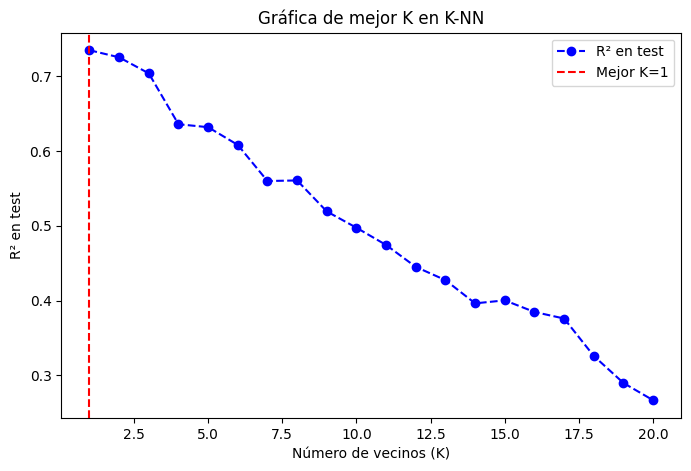

El mejor valor de K es: 1
El mejor R² alcanzado en test es: 0.7346089831444034


In [95]:
import matplotlib.pyplot as plt

valores_prueba = range(1, 21)
r2_scores = []

for valor in valores_prueba:
    knn = KNeighborsRegressor(n_neighbors=valor)
    knn.fit(X_train, y_train)
    r2_scores.append(knn.score(X_test, y_test))

mejor_k_valor = valores_prueba[np.argmax(r2_scores)]
mejor_r2_score = max(r2_scores)

plt.figure(figsize=(8, 5))
plt.plot(valores_prueba, r2_scores, marker='o', linestyle='dashed', color='b', label="R² en test")
plt.axvline(mejor_k_valor, color='r', linestyle='--', label=f'Mejor K={mejor_k_valor}')
plt.xlabel("Número de vecinos (K)")
plt.ylabel("R² en test")
plt.title("Gráfica de mejor K en K-NN")
plt.legend()
plt.show()

print(f"El mejor valor de K es: {mejor_k_valor}")
print(f"El mejor R² alcanzado en test es: {mejor_r2_score}")